**Author**: Felipe Matheus <br>
**Start Date**: 14/04/2026 <br>
**End Date**: --/--/2026 <br>
**Related Links**:
- `eda_clusterization.ipynb` — exploratory analysis
- `data/raw/elements_composition/compositions.py` — raw sample dicts

**Objective:**

Apply unsupervised clustering (K-Means, K-Means++, Hierarchical, GMM) with K ∈ {2, 3, 4} across three datasets derived from the SPECTRO Cu-10-F measurements:
- **Dataset A** — original 9 samples (point estimates)
- **Dataset B** — 100 Monte Carlo draws per sample, `below_limit_zero=True` (900 rows)
- **Dataset C** — 100 Monte Carlo draws per sample, `below_limit_zero=False` (900 rows)

---
## 1 · Setup

In [1]:
import os
import sys
import warnings
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.DataLoader import DataLoader as load
from src.feature_engineering.FeatureEngineering import FeatureEngineering as fe
from src.modeling.modeling import Modeling as mod

warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

In [2]:
SEED = 42
KS   = (2, 3, 4)
N_MC = 100          # Monte Carlo draws per sample

---
## 2 · Load compositions

In [3]:
compositions_path = os.path.abspath(os.path.join('../../data/raw/elements_composition'))
if compositions_path not in sys.path:
    sys.path.append(compositions_path)

from compositions import (
    sac_1A_sac1,
    sac_1A_sac2,
    sac_1B_sac1,
    sac_1B_sac2,
    sac_1B_sac3,
    sac_1B_sac4,
    sac_1B_sac6,
    sac_2N_sac1,
    sac_2N_sac2,
    ALL_SAMPLES,
)

print(f"{len(ALL_SAMPLES)} samples loaded: {list(ALL_SAMPLES.keys())}")

9 samples loaded: ['1A sac1', '1A sac2', '1B sac1', '1B sac2', '1B sac3', '1B sac4', '1B sac6', '2N sac1', '2N sac2']


---
## 3 · Build datasets

### Dataset A — Original point estimates (9 rows)
One row per sample using the raw mean concentrations.  
`below_limit_zero=False` keeps detection-limit values as their nominal measurement.

In [4]:
df_A = pd.DataFrame(
    {name: load.to_flat(sample, below_limit_zero=False)
     for name, sample in ALL_SAMPLES.items()}
).T

df_A.index.name = "sample"
print(f"Dataset A shape: {df_A.shape}")
df_A

Dataset A shape: (9, 26)


,Zn,Pb,Sn,P,Mn,Fe,Ni,Si,Mg,Cr,...,Al,S,Be,Zr,Au,B,Ti,Pt,Cu,Te
sample,,,,,,,,,,,,,,,,,,,,,
1A sac1,0.0010,0.0003,0.0002,0.00020,0.0004,0.00110,0.00020,0.00100,0.00026,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00047,0.00020,0.002,99.98,0.0017
1A sac2,0.0010,0.0003,0.0002,0.00020,0.0004,0.00110,0.00020,0.00100,0.00026,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00047,0.00020,0.002,99.98,0.0019
1B sac1,0.0014,0.0003,0.0137,0.00020,0.0004,0.00120,0.00020,0.00110,0.00021,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00051,0.00020,0.002,99.97,0.0020
1B sac2,0.0011,0.0003,0.0037,0.00020,0.0004,0.00088,0.00020,0.00088,0.00017,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00043,0.00020,0.002,99.98,0.0020
1B sac3,0.0014,0.0100,0.0033,0.00020,0.0004,0.00079,0.00020,0.00095,0.00021,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00040,0.00020,0.002,99.97,0.0021
1B sac4,0.0101,0.0053,0.0199,0.00026,0.0004,0.00150,0.00020,0.00170,0.00031,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00048,0.00024,0.002,99.95,0.0029
1B sac6,0.0010,0.0003,0.0195,0.00020,0.0004,0.00090,0.00020,0.00084,0.00017,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00043,0.00020,0.002,99.96,0.0022
2N sac1,0.0061,0.0332,0.0060,0.00020,0.0004,0.00130,0.00034,0.00080,0.00017,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00046,0.00020,0.002,99.94,0.0021
2N sac2,0.0010,0.3020,0.0055,0.00020,0.0004,0.00120,0.00020,0.00085,0.00017,0.0003,...,0.0005,0.0002,0.0001,0.0003,0.0006,0.00045,0.00020,0.002,99.67,0.0020


### Dataset B — Monte Carlo · `below_limit_zero=True` (900 rows)
100 draws per sample. Below-detection elements are fixed at **0.0** — no variance injected for uncertain values.

In [5]:
frames_B = []
for name, sample in ALL_SAMPLES.items():
    draws = fe.monte_carlo(sample, n=N_MC, below_limit_zero=True, seed=SEED)
    draws["sample_name"] = name
    frames_B.append(draws)

df_B = pd.concat(frames_B, ignore_index=True)

print(f"Dataset B shape: {df_B.shape}")
df_B.head()

Dataset B shape: (900, 27)


,Zn,Pb,Sn,P,Mn,Fe,Ni,Si,Mg,Cr,...,S,Be,Zr,Au,B,Ti,Pt,Cu,Te,sample_name
0,0.0,0.0,0.0,0.0,0.0,0.001167,0.0,0.000966,0.000263,0.0,...,0.0,0.0,0.0,0.0,0.000516,0.0,0.0,99.98,0.001978,1A sac1
1,0.0,0.0,0.0,0.0,0.0,0.000871,0.0,0.001117,0.000274,0.0,...,0.0,0.0,0.0,0.0,0.000418,0.0,0.0,99.98,0.001639,1A sac1
2,0.0,0.0,0.0,0.0,0.0,0.001265,0.0,0.000968,0.000261,0.0,...,0.0,0.0,0.0,0.0,0.000585,0.0,0.0,99.98,0.001442,1A sac1
3,0.0,0.0,0.0,0.0,0.0,0.001307,0.0,0.001066,0.000266,0.0,...,0.0,0.0,0.0,0.0,0.000414,0.0,0.0,99.98,0.001686,1A sac1
4,0.0,0.0,0.0,0.0,0.0,0.000671,0.0,0.000916,0.000239,0.0,...,0.0,0.0,0.0,0.0,0.000413,0.0,0.0,99.98,0.001962,1A sac1


### Dataset C — Monte Carlo · `below_limit_zero=False` (900 rows)
100 draws per sample. Below-detection elements are **also sampled** from N(val, sd) using the detection-limit value as mean — propagates uncertainty even for near-limit elements.

In [6]:
frames_C = []
for name, sample in ALL_SAMPLES.items():
    draws = fe.monte_carlo(sample, n=N_MC, below_limit_zero=False, seed=SEED)
    draws["sample_name"] = name
    frames_C.append(draws)

df_C = pd.concat(frames_C, ignore_index=True)

print(f"Dataset C shape: {df_C.shape}")
df_C.head()

Dataset C shape: (900, 27)


,Zn,Pb,Sn,P,Mn,Fe,Ni,Si,Mg,Cr,...,S,Be,Zr,Au,B,Ti,Pt,Cu,Te,sample_name
0,0.001,0.0003,0.0002,0.0002,0.0004,0.001167,0.0002,0.000966,0.000263,0.0003,...,0.0002,0.0001,0.0003,0.0006,0.000516,0.0002,0.002,99.98,0.001978,1A sac1
1,0.001,0.0003,0.0002,0.0002,0.0004,0.000871,0.0002,0.001117,0.000274,0.0003,...,0.0002,0.0001,0.0003,0.0006,0.000418,0.0002,0.002,99.98,0.001639,1A sac1
2,0.001,0.0003,0.0002,0.0002,0.0004,0.001265,0.0002,0.000968,0.000261,0.0003,...,0.0002,0.0001,0.0003,0.0006,0.000585,0.0002,0.002,99.98,0.001442,1A sac1
3,0.001,0.0003,0.0002,0.0002,0.0004,0.001307,0.0002,0.001066,0.000266,0.0003,...,0.0002,0.0001,0.0003,0.0006,0.000414,0.0002,0.002,99.98,0.001686,1A sac1
4,0.001,0.0003,0.0002,0.0002,0.0004,0.000671,0.0002,0.000916,0.000239,0.0003,...,0.0002,0.0001,0.0003,0.0006,0.000413,0.0002,0.002,99.98,0.001962,1A sac1


---
## 4 · Visualization helper

In [7]:
ALGOS  = ["KMeans", "KMeans++", "Hierarchical", "GMM"]
COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red",
          "tab:purple", "tab:brown", "tab:pink"]


def plot_clusters_pca(df_feat: pd.DataFrame, results: dict, title: str) -> None:
    """PCA 2-D scatter: rows = K values, columns = algorithms."""
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    numeric = df_feat.select_dtypes(include="number")
    non_const = numeric.loc[:, numeric.std() > 0]
    X_scaled = StandardScaler().fit_transform(non_const.values)
    coords = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)

    n_rows, n_cols = len(KS), len(ALGOS)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)

    for r, k in enumerate(KS):
        for c, algo in enumerate(ALGOS):
            ax = axes[r, c]
            labels = results[algo][k]["labels"]
            sil    = results[algo][k]["silhouette"]
            for cluster_id in range(k):
                mask = labels == cluster_id
                ax.scatter(
                    coords[mask, 0], coords[mask, 1],
                    c=COLORS[cluster_id], label=f"C{cluster_id}",
                    alpha=0.7, s=30, edgecolors="none"
                )
            ax.set_title(f"{algo} · K={k}\nSil={sil:.3f}", fontsize=9)
            ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
            ax.legend(fontsize=7, markerscale=1.2)

    plt.tight_layout()
    plt.show()


def plot_silhouette_heatmap(summary: pd.DataFrame, title: str) -> None:
    """Heatmap of silhouette scores: algorithms vs K."""
    sil = summary["Silhouette"].unstack(level="K")
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.heatmap(
        sil, annot=True, fmt=".3f", cmap="YlGn",
        linewidths=0.5, ax=ax, vmin=0, vmax=1
    )
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## 5 · Clustering — Dataset A (Original, 9 samples)

In [8]:
summary_A, results_A = mod.run_all(df_A, ks=KS, seed=SEED)
summary_A

Silhouette  Inertia     BIC     AIC
Algorithm    K                                     
GMM          2      0.1671      NaN -221.17 -274.62
             3      0.1506      NaN -316.25 -396.52
             4      0.1699      NaN -135.70 -242.79
Hierarchical 2      0.4482      NaN     NaN     NaN
             3      0.2457      NaN     NaN     NaN
             4      0.2199      NaN     NaN     NaN
KMeans       2      0.4482  73.5433     NaN     NaN
             3      0.1504  53.1714     NaN     NaN
             4      0.2199  31.5732     NaN     NaN
KMeans++     2      0.4482  73.5433     NaN     NaN
             3      0.2457  50.8620     NaN     NaN
             4      0.2199  31.5732     NaN     NaN

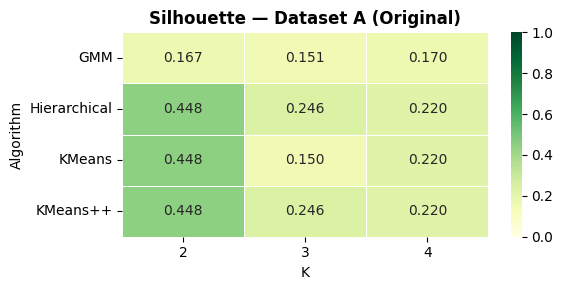

In [9]:
plot_silhouette_heatmap(summary_A, "Silhouette — Dataset A (Original)")

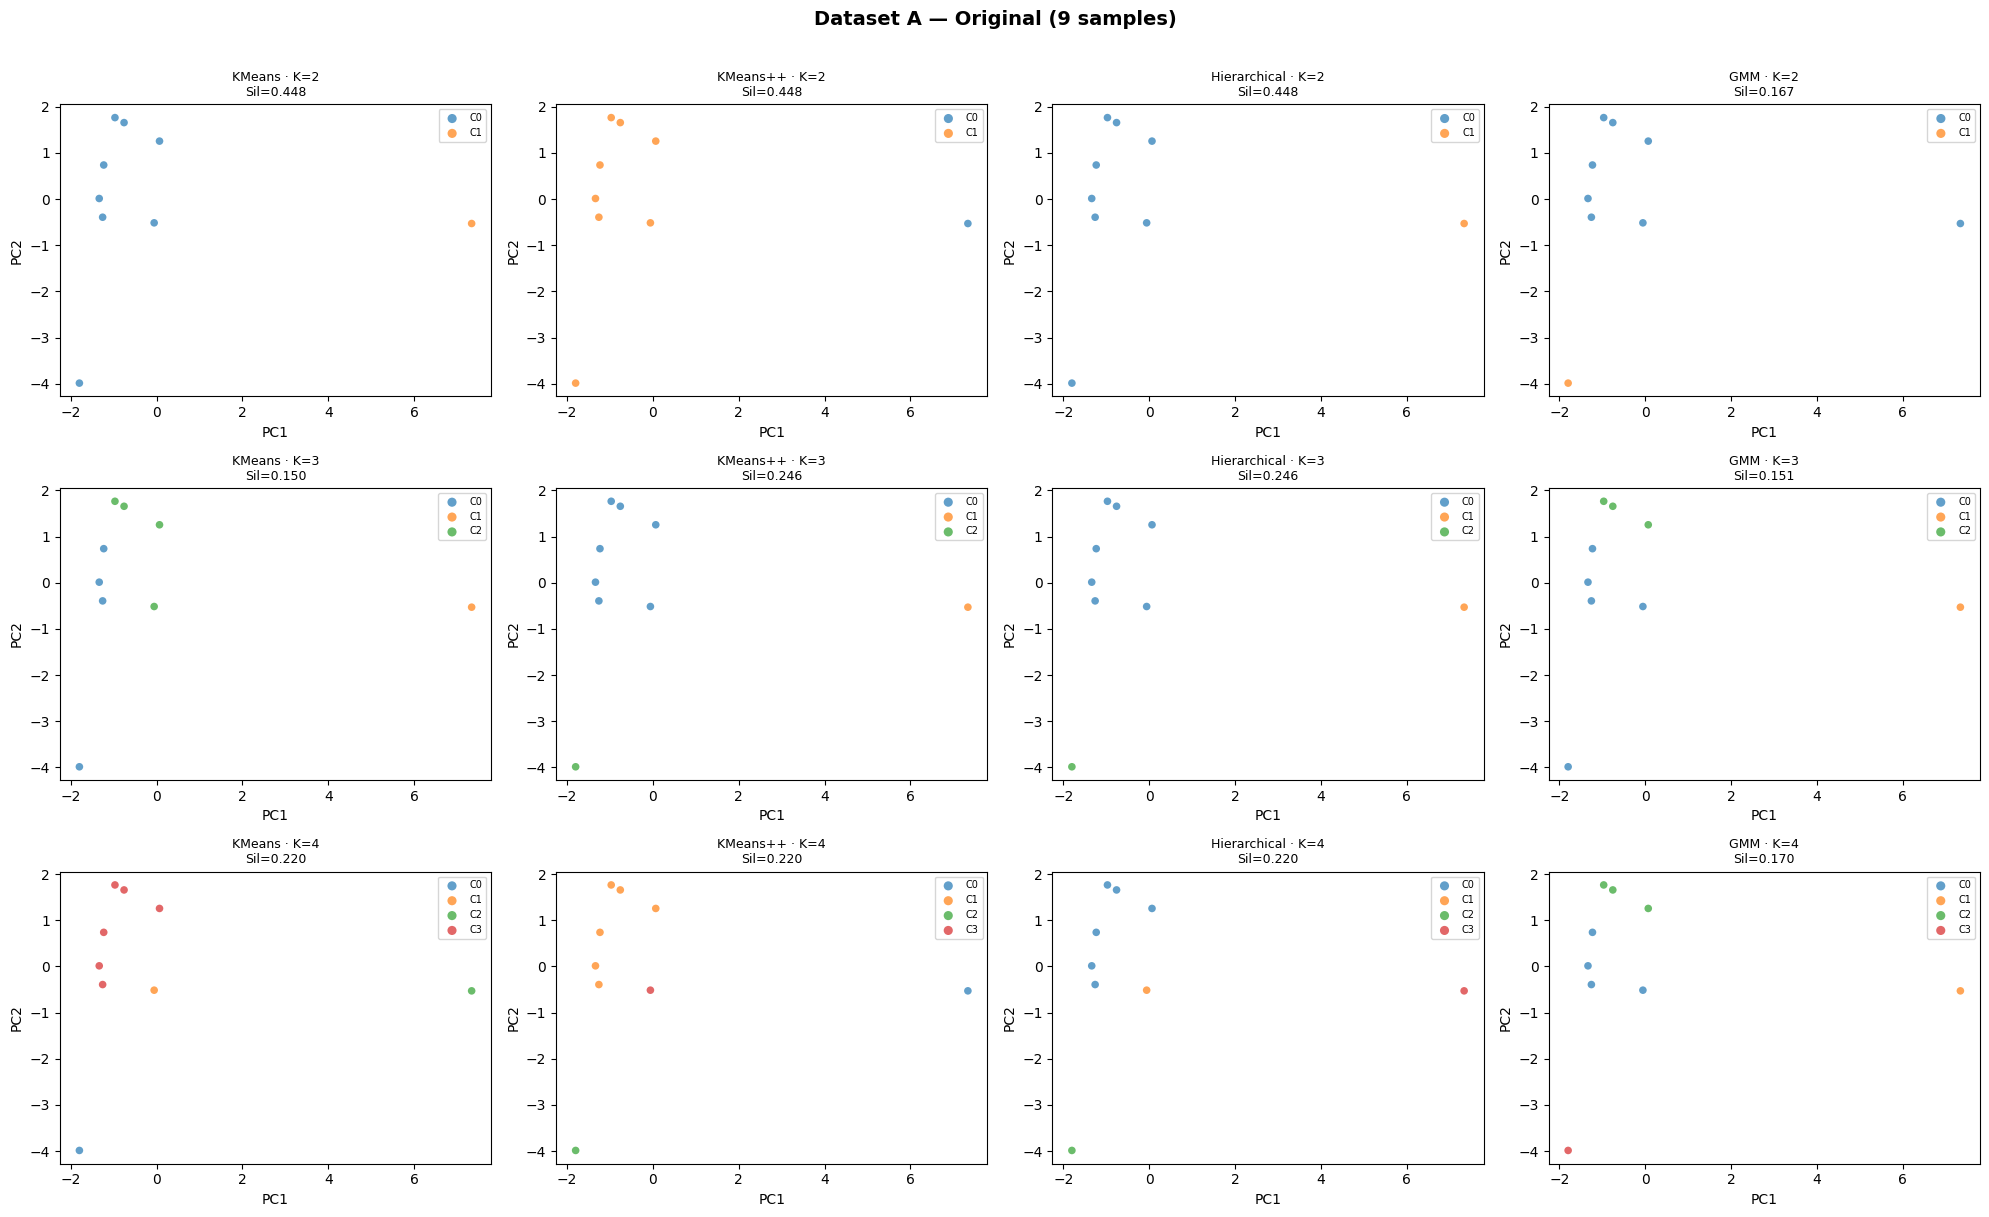

In [10]:
plot_clusters_pca(df_A, results_A, "Dataset A — Original (9 samples)")

---
## 6 · Clustering — Dataset B (MC · `below_limit_zero=True`, 900 rows)

In [11]:
df_B_feat = df_B.drop(columns=["sample_name"])

summary_B, results_B = mod.run_all(df_B_feat, ks=KS, seed=SEED)
summary_B

Silhouette    Inertia       BIC       AIC
Algorithm    K                                           
GMM          2      0.2804        NaN   8976.50   7675.05
             3      0.3909        NaN -16473.54 -18428.11
             4      0.4506        NaN -23831.89 -26439.59
Hierarchical 2      0.4797        NaN       NaN       NaN
             3      0.3843        NaN       NaN       NaN
             4      0.4506        NaN       NaN       NaN
KMeans       2      0.4797  9034.9946       NaN       NaN
             3      0.3843  6983.8452       NaN       NaN
             4      0.4506  5044.0357       NaN       NaN
KMeans++     2      0.4797  9034.9946       NaN       NaN
             3      0.3920  7006.1281       NaN       NaN
             4      0.4506  5044.0357       NaN       NaN

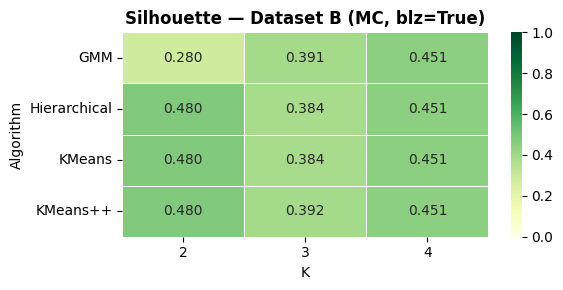

In [12]:
plot_silhouette_heatmap(summary_B, "Silhouette — Dataset B (MC, blz=True)")

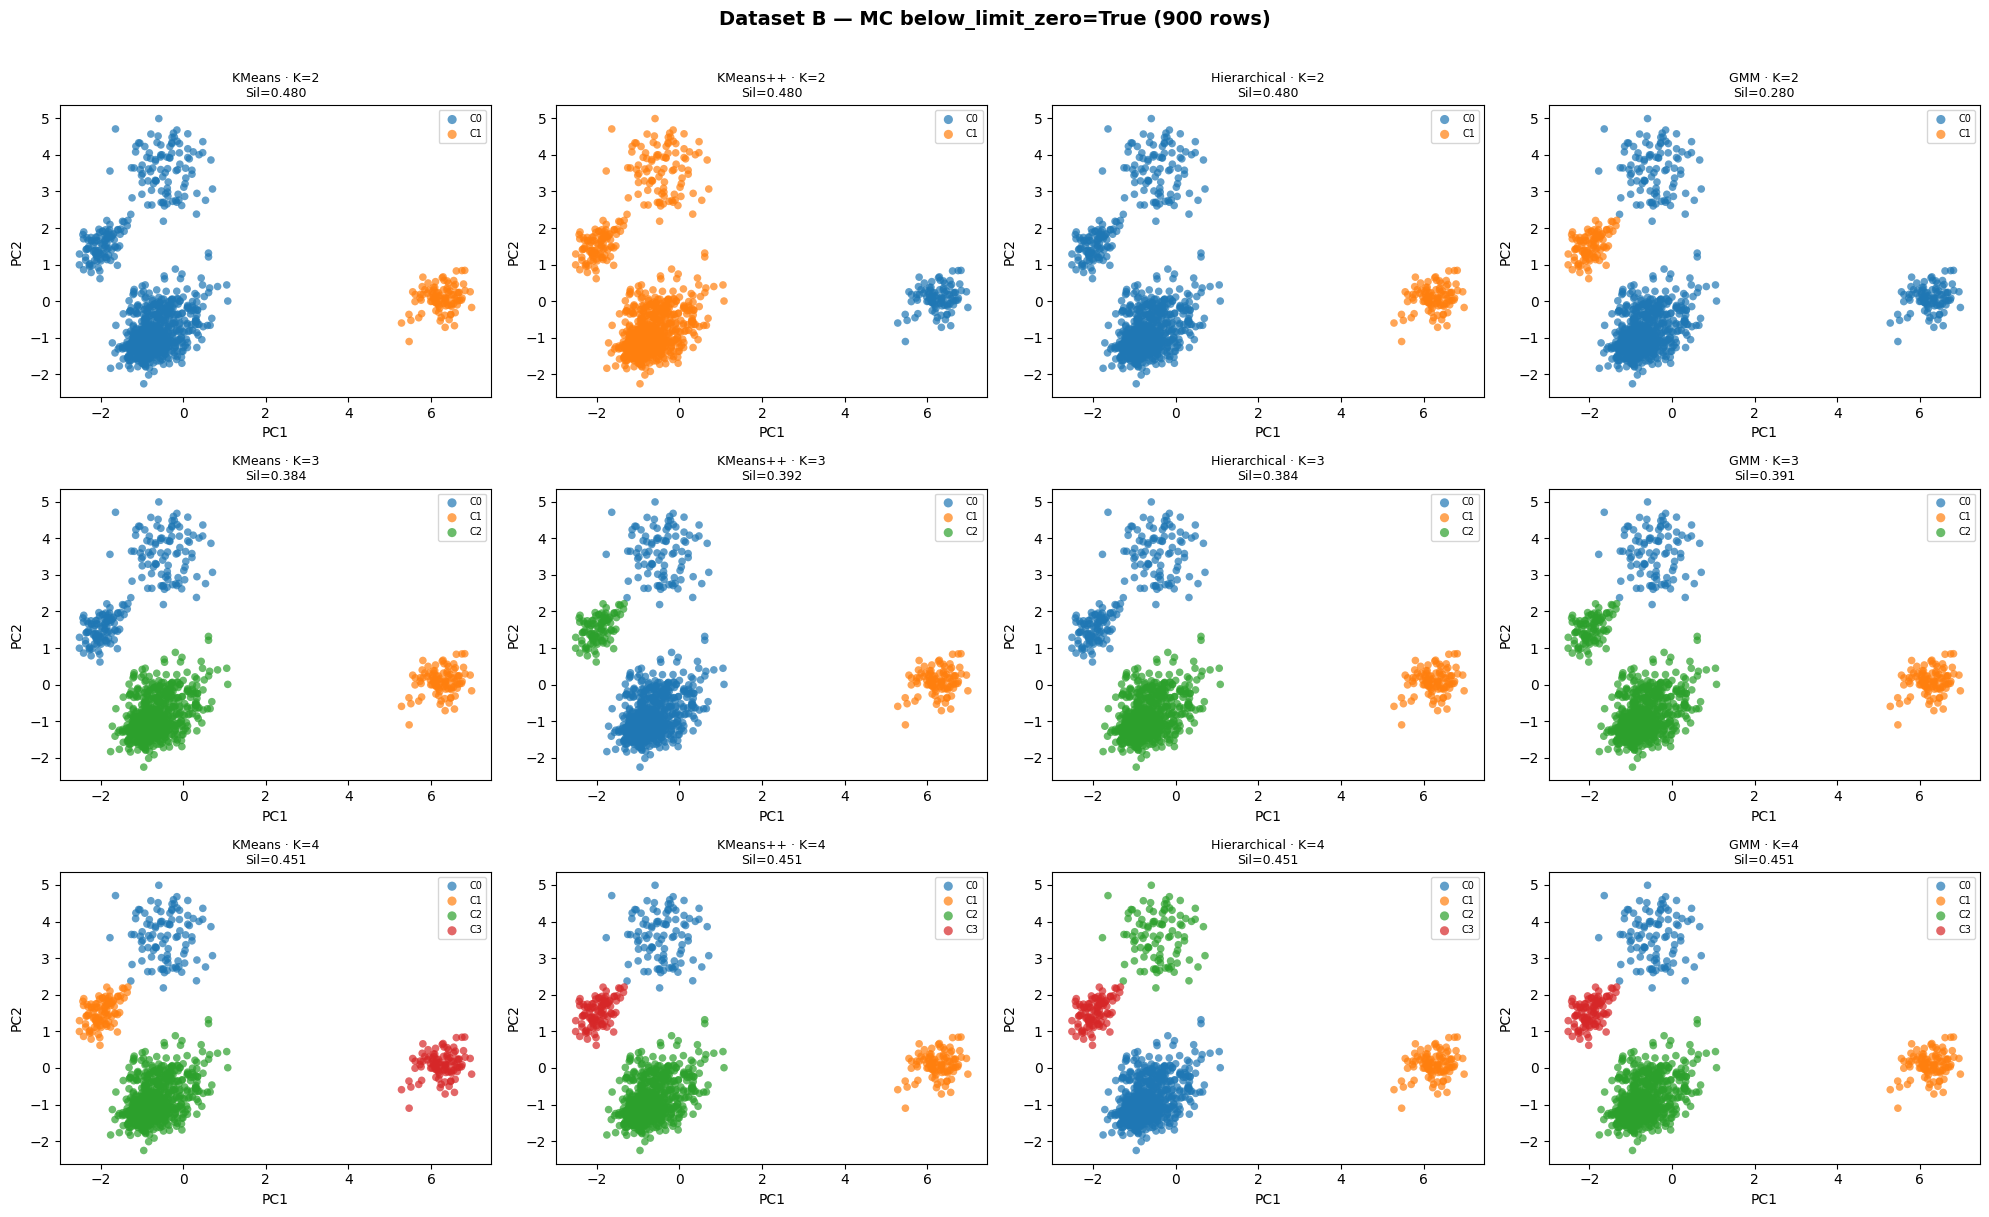

In [13]:
plot_clusters_pca(df_B_feat, results_B, "Dataset B — MC below_limit_zero=True (900 rows)")

---
## 7 · Clustering — Dataset C (MC · `below_limit_zero=False`, 900 rows)

In [14]:
df_C_feat = df_C.drop(columns=["sample_name"])

summary_C, results_C = mod.run_all(df_C_feat, ks=KS, seed=SEED)
summary_C

Silhouette    Inertia        BIC        AIC
Algorithm    K                                             
GMM          2      0.2803        NaN -101293.24 -104919.05
             3      0.3087        NaN -129642.95 -135084.07
             4      0.3896        NaN -134662.02 -141918.44
Hierarchical 2      0.4735        NaN        NaN        NaN
             3      0.3791        NaN        NaN        NaN
             4      0.3896        NaN        NaN        NaN
KMeans       2      0.4735  9239.3832        NaN        NaN
             3      0.3791  7217.8486        NaN        NaN
             4      0.3978  5862.0209        NaN        NaN
KMeans++     2      0.4735  9239.3832        NaN        NaN
             3      0.3791  7217.8486        NaN        NaN
             4      0.3978  5862.0209        NaN        NaN

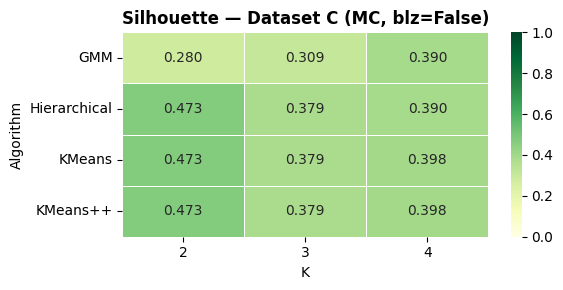

In [15]:
plot_silhouette_heatmap(summary_C, "Silhouette — Dataset C (MC, blz=False)")

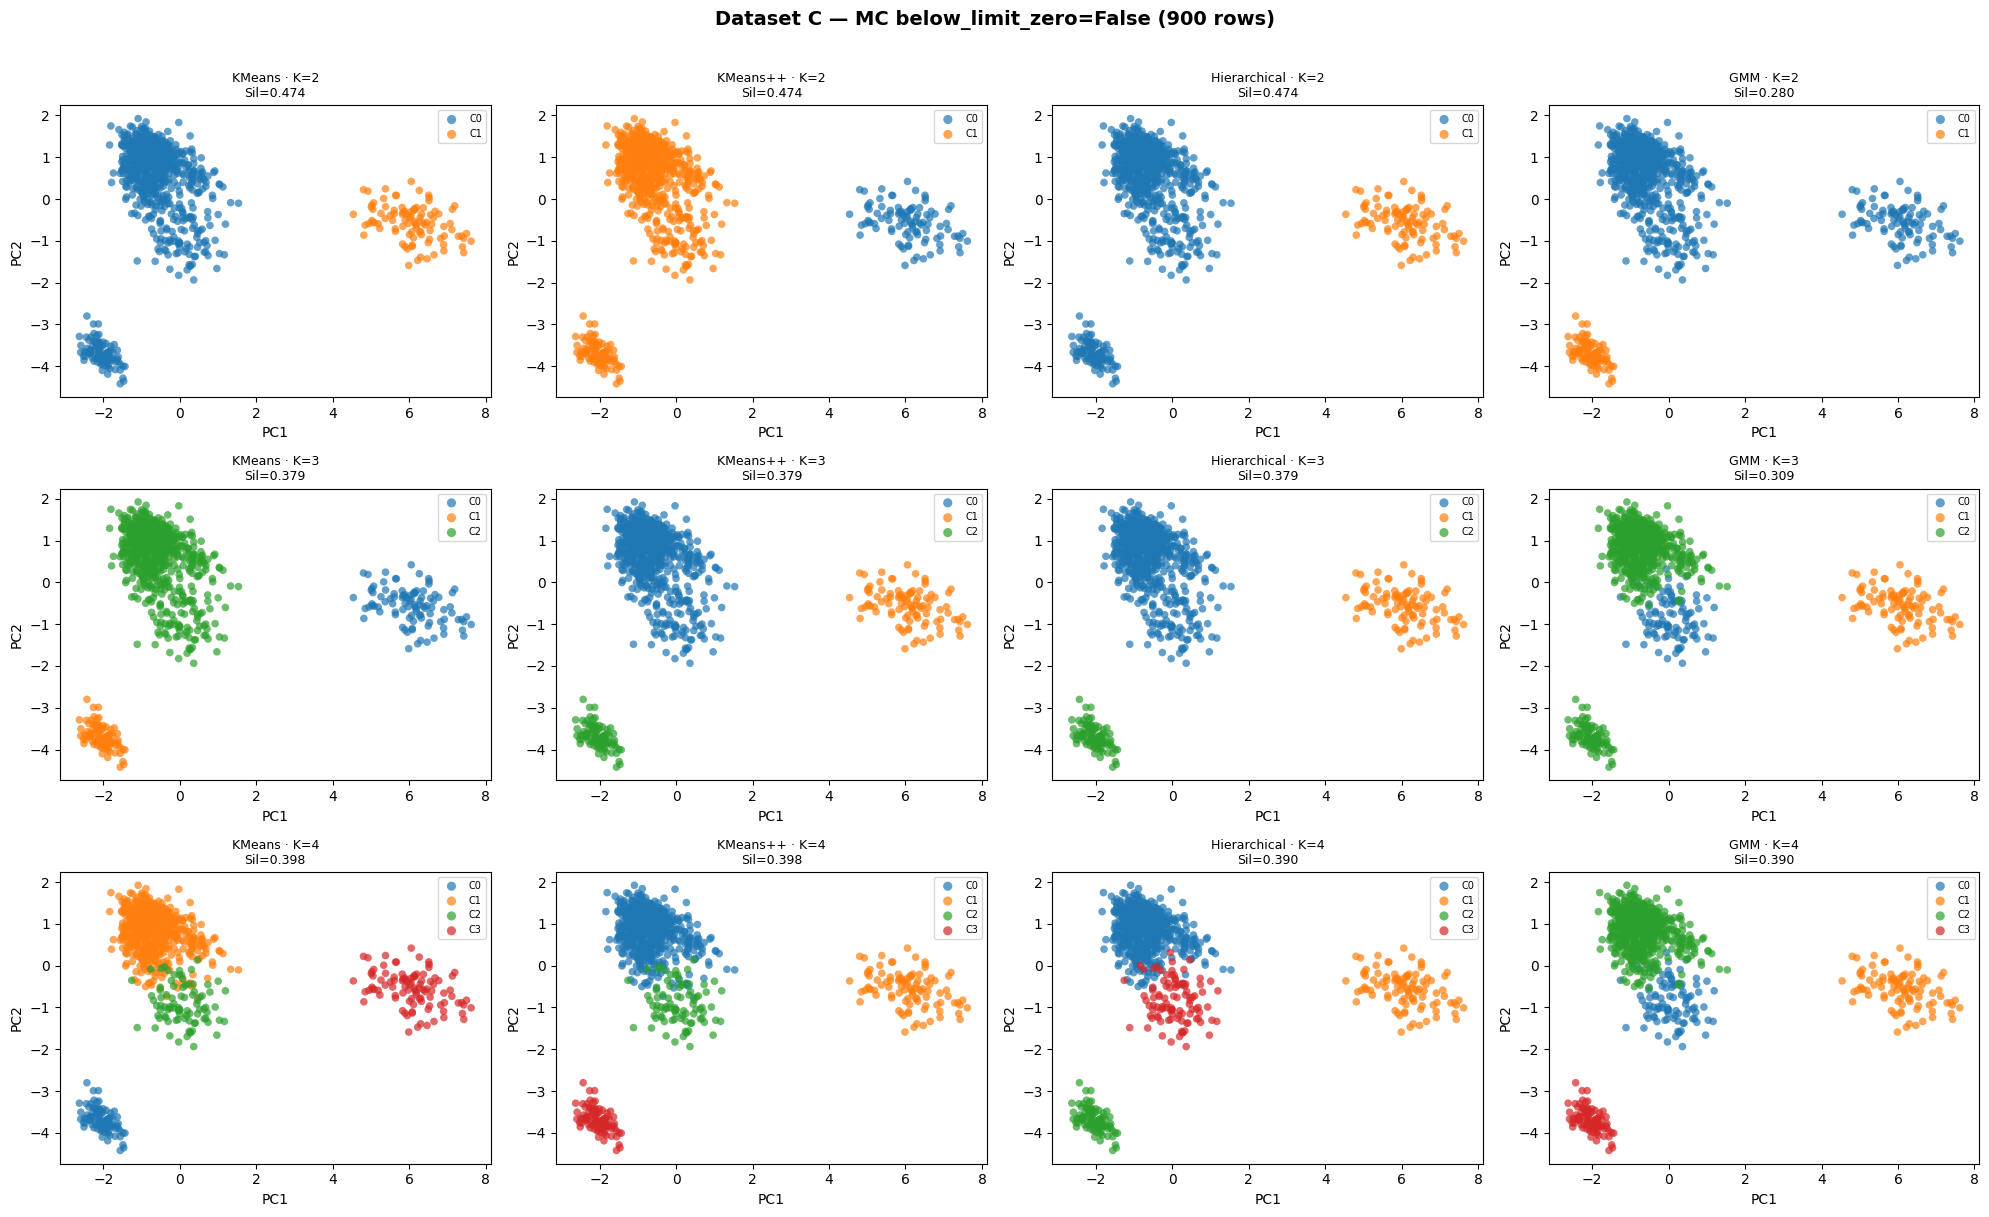

In [16]:
plot_clusters_pca(df_C_feat, results_C, "Dataset C — MC below_limit_zero=False (900 rows)")

---
## 8 · Cross-dataset comparison

In [17]:
def add_dataset_label(summary: pd.DataFrame, label: str) -> pd.DataFrame:
    df = summary[["Silhouette"]].copy()
    df.columns = pd.MultiIndex.from_tuples([(label, "Silhouette")])
    return df

comparison = pd.concat([
    add_dataset_label(summary_A, "A · Original"),
    add_dataset_label(summary_B, "B · MC blz=True"),
    add_dataset_label(summary_C, "C · MC blz=False"),
], axis=1)

comparison

A · Original B · MC blz=True C · MC blz=False
                 Silhouette      Silhouette       Silhouette
Algorithm    K                                              
GMM          2       0.1671          0.2804           0.2803
             3       0.1506          0.3909           0.3087
             4       0.1699          0.4506           0.3896
Hierarchical 2       0.4482          0.4797           0.4735
             3       0.2457          0.3843           0.3791
             4       0.2199          0.4506           0.3896
KMeans       2       0.4482          0.4797           0.4735
             3       0.1504          0.3843           0.3791
             4       0.2199          0.4506           0.3978
KMeans++     2       0.4482          0.4797           0.4735
             3       0.2457          0.3920           0.3791
             4       0.2199          0.4506           0.3978

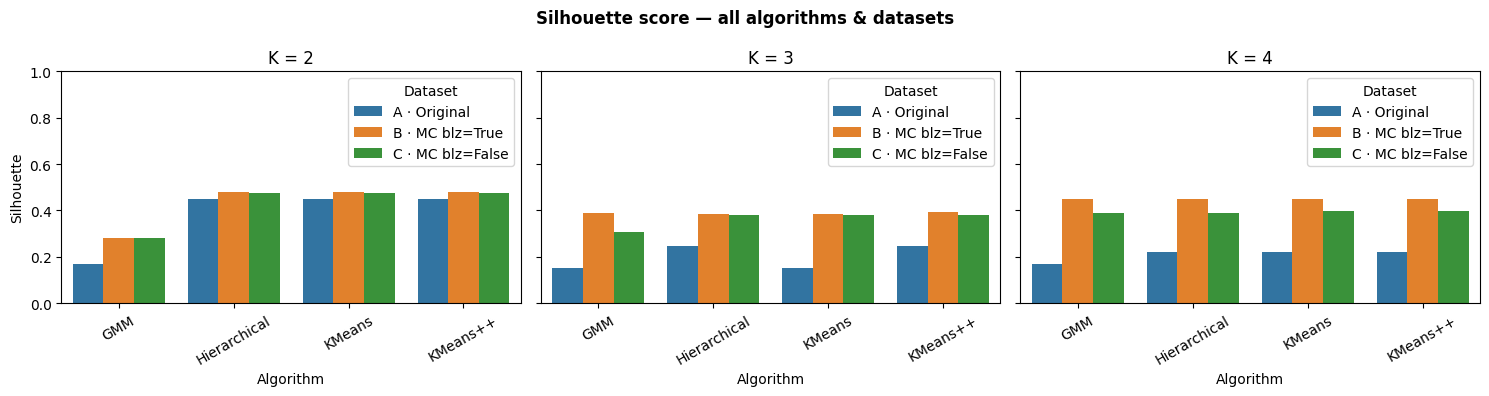

In [18]:
comp_flat = pd.concat([
    summary_A[["Silhouette"]].assign(Dataset="A · Original"),
    summary_B[["Silhouette"]].assign(Dataset="B · MC blz=True"),
    summary_C[["Silhouette"]].assign(Dataset="C · MC blz=False"),
]).reset_index()

fig, axes = plt.subplots(1, len(KS), figsize=(5 * len(KS), 4), sharey=True)
fig.suptitle("Silhouette score — all algorithms & datasets", fontweight="bold")

for ax, k in zip(axes, KS):
    subset = comp_flat[comp_flat["K"] == k]
    sns.barplot(
        data=subset, x="Algorithm", y="Silhouette",
        hue="Dataset", ax=ax
    )
    ax.set_title(f"K = {k}")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()